### Notebook for training LSTM model with a Kaggke API Key

In [7]:
!nvidia-smi
import os, sys
print("CWD:", os.getcwd())
print("FILES:", os.listdir())
sys.path.insert(0, os.getcwd())  # pour importer tes .py à la racine


zsh:1: command not found: nvidia-smi
CWD: /Users/killianguillaume/Desktop/Forecast_MP
FILES: ['Forecast', 'test_UI_tryout.py', '.kaggleignore', 'prediction_lstm_model.py', '.DS_Store', 'data_preprocessing.py', 'notebook_train.ipynb', '.streamlit', 'kernel-metadata.json', 'checkpoints', 'save_model.py', '__pycache__', 'results', 'etf_collector.py', 'logo_QuantIA.png', '.gitignore', '.env', '.venv', 'streamlit_app_sections.py', 'app.py', '.git', 'client_UI.py', 'main.py', 'plot_prediction.py', 'pages', 'services', 'etf_visualizer.py']


In [ ]:
# --- Bootstrap Kaggle/local ---
from pathlib import Path
import os, sys, torch, platform, time

# Dossier de travail pour outputs (Kaggle ou local)
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUT_DIR = WORK_DIR / "Forecast" / "artifacts" / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("OUT_DIR:", OUT_DIR)
# Diagnostiques utiles
try:
    import subprocess; subprocess.run(["nvidia-smi"])
except Exception: pass
print("CUDA:", torch.cuda.is_available())

# Si tes modules .py sont à la racine du projet que tu as poussé
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


In [ ]:
from pathlib import Path
from typing import List, Dict, Tuple


from main import run_lstm_training

CWD: /Users/killianguillaume/Desktop/Forecast_MP
FILES: ['Forecast', 'test_UI_tryout.py', 'prediction_lstm_model.py', '.DS_Store', 'data_preprocessing.py', 'notebook_train.ipynb', '.streamlit', 'kernel-metadata.json', 'checkpoints', 'save_model.py', '__pycache__', 'results', 'etf_collector.py', 'logo_QuantIA.png', '.gitignore', '.env', '.venv', 'streamlit_app_sections.py', 'app.py', '.git', 'client_UI.py', 'main.py', 'plot_prediction.py', 'pages', 'services', 'etf_visualizer.py']


In [ ]:
# paths.py (par ex.)  — crée ce petit module utilitaire
from pathlib import Path
import time

def resolve_work_dir() -> Path:
    """Renvoie /kaggle/working si dispo, sinon le dossier courant."""
    return Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

def resolve_save_dir(project_name="Forecast") -> Path:
    base = resolve_work_dir() / project_name / "artifacts" / "models"
    run = time.strftime("%Y%m%d-%H%M%S")
    save_dir = base / run
    save_dir.mkdir(parents=True, exist_ok=True)
    return save_dir


In [2]:
DEFAULT_TRAIN_TICKERS: List[str] = [ "SPY", "ISF.L", "CAC.PA", "EXS1.DE", "IAEX.AS", "1321.T", "XIC.TO", "2800.HK", "STW.AX", "510300.SS",
                                   "IEAG.L","IEAC.AS","EUNH.DE","CBE0.L","IEGS.L","IGLN.L","SSLN.L","CMOD.L","OILB.L",
                                   "ASML.AS","SAP.DE","MC.PA","AIR.PA","OR.PA","SAN.PA","RMS.PA","NESN.SW","ROG.SW","NOVN.SW","SHEL.L","BP.L","TTE.PA",
                                    "QQQ","IWM","VTI","VT","EFA","VEA","EEM","VWO",
                                    "VNQ",                       # REITs
                                    "XLK","XLF","XLV","XLE","XLY","XLP","XLI","XLB","XLC","XLU",  # secteurs
                                    "TLT","IEF","BND","HYG","LQD",  # obligations
                                    "GLD","SLV","DBC","USO",        # matières premières
                                    "AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","BRK-B",
                                    "EWJ","EWG","EWQ","EWA","EWC","EWH","EWT","EWS","EWZ","EZA",
                                    "6758.T","7203.T","9984.T",        # Sony, Toyota, SoftBank
                                    "0700.HK","9988.HK","3690.HK",     # Tencent, Alibaba, Meituan
                                    "RY.TO","TD.TO","SHOP.TO","ENB.TO","BHP.AX","CBA.AX"# Canada & Australie
                                   ]

DEFAULT_TRAIN_TICKERS: List[str] = [ "SPY"]#, "ISF.L", "CAC.PA", "EXS1.DE", "IAEX.AS", "1321.T", "XIC.TO", "2800.HK", "STW.AX", "510300.SS"]
FOREX_TICKERS: Dict[str, str] = {
    "EURUSD=X": "FX_EURUSD",
    "GBPUSD=X": "FX_GBPUSD",
    "USDJPY=X": "FX_USDJPY",
}

LSTM_FEATURE_COLUMNS: List[str] = [
    "volume_log",
    "ret",
    "ret_mean_5",
    "ret_mean_20",
    "ret_mean_50",
    "ret_std_20",
    "ret_std_50",
    "price_zscore_20",
    "RSI_14",
] + [f"{alias}_RET" for alias in FOREX_TICKERS.values()]

TARGET_COLUMN: str = "ret"

hp = {
    "window_size": 60, #100
    "hidden_size": 48, #64
    "num_layers": 1, #2
    "lr": 1e-3,
    "epochs": 700, #200
    "horizon": 10,
    "residual_boosting": False,
}

hp_small = {
    "window_size": 1, #100
    "hidden_size": 1, #64
    "num_layers": 1, #2
    "lr": 1e-3,
    "epochs": 1, #200
    "horizon": 10,
    "residual_boosting": False,
}

In [ ]:
# === À faire AVANT l'entraînement ===
save_dir = resolve_save_dir("Forecast")
best_path = save_dir / "best.pt"   # meilleur modèle (val la + basse)
last_path = save_dir / "last.pt"   # dernier état (pour reprise)
print("Saving to:", save_dir)

Saving to: /Users/killianguillaume/Desktop/Forecast_MP/Forecast/artifacts/models/20251030-184746


Séries retenues pour l'entraînement :
  • SPY: 5514 observations après préparation
  • FX_EURUSD: 5637 observations après préparation
  • FX_GBPUSD: 5649 observations après préparation
  • FX_USDJPY: 5685 observations après préparation
modele training with 4 series, window_size=1
on rentre danns le training
init du modele ok
Démarrage de l'entraînement...
data goes from 2003-12-02 to 2025-10-30 with 5716 unique dates across all assets.

5 plis de validation croisée (walk-forward) ont été définis.
  Pli 1: Train [2003-12-02 -> 2007-06-01], Val [2007-06-04 -> 2010-11-26]
  Pli 2: Train [2003-12-02 -> 2010-11-26], Val [2010-11-29 -> 2014-05-23]
  Pli 3: Train [2003-12-02 -> 2014-05-23], Val [2014-05-26 -> 2017-11-17]
  Pli 4: Train [2003-12-02 -> 2017-11-17], Val [2017-11-20 -> 2021-05-14]
  Pli 5: Train [2003-12-02 -> 2021-05-14], Val [2021-05-17 -> 2024-11-08]

--- Démarrage Pli 1/5 ---
  Train: 2003-12-02 -> 2007-06-01
  Val:   2007-06-04 -> 2010-11-26
  Ajustement des scalers sur les 

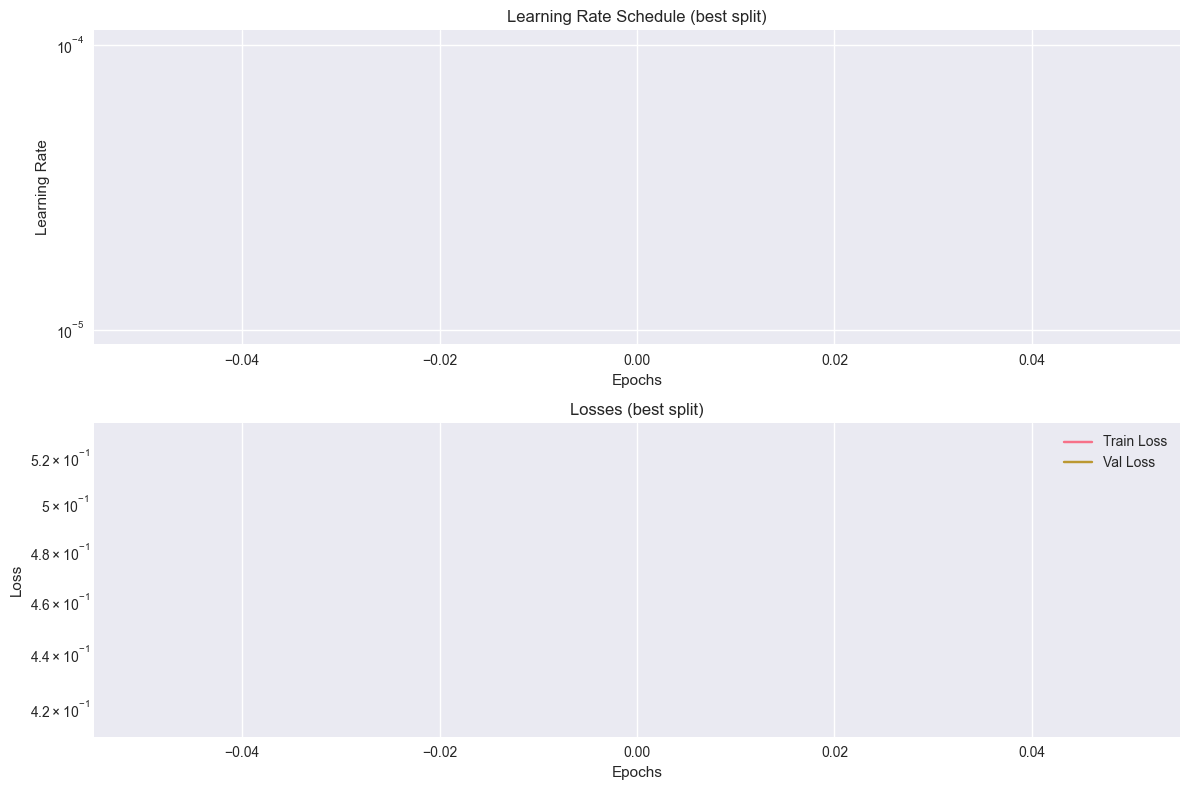

on a plot
on a fini
💾 Modèle sauvegardé dans: /Users/killianguillaume/Desktop/Forecast_MP/Forecast/artifacts/models/20251030-184746
✅ Entraînement terminé et modèle sauvegardé.
📦 Modèle chargé depuis: /Users/killianguillaume/Desktop/Forecast_MP/Forecast/artifacts/models/20251030-184746
modele chargé depuis /Users/killianguillaume/Desktop/Forecast_MP/Forecast/artifacts/models/20251030-184746
features: ['volume_log', 'ret', 'ret_mean_5', 'ret_mean_20', 'ret_mean_50', 'ret_std_20', 'ret_std_50', 'price_zscore_20', 'RSI_14', 'FX_EURUSD_RET', 'FX_GBPUSD_RET', 'FX_USDJPY_RET']
df columns: ['volume_log', 'ret', 'ret_mean_5', 'ret_mean_20', 'ret_mean_50', 'ret_std_20', 'ret_std_50', 'price_zscore_20', 'RSI_14', 'FX_EURUSD_RET', 'FX_GBPUSD_RET', 'FX_USDJPY_RET', 'adj_close']


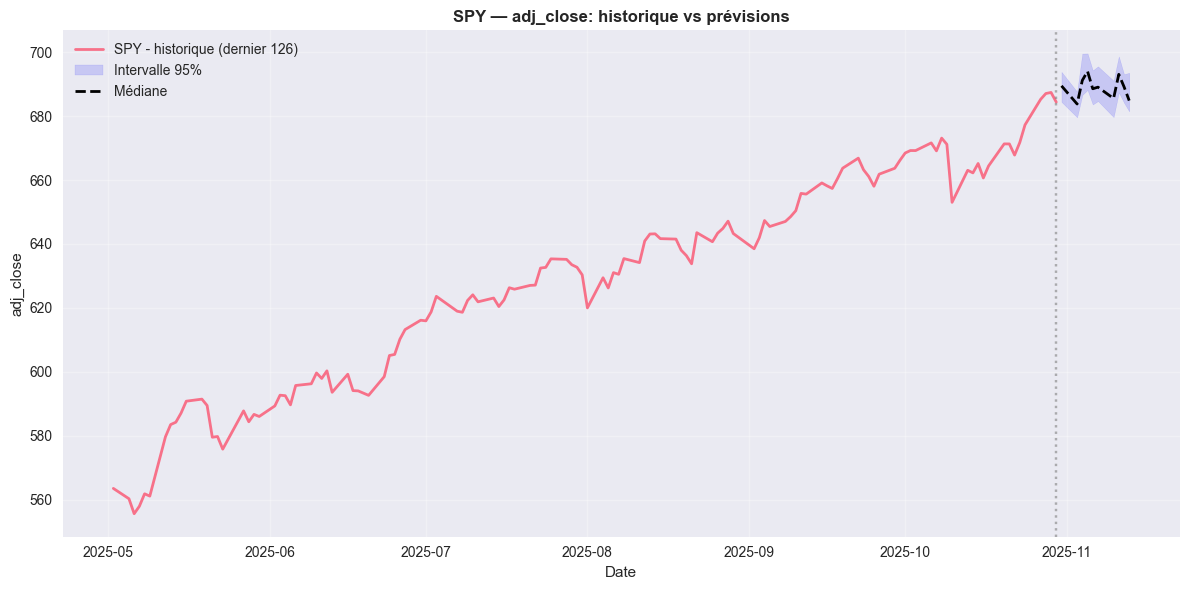

In [ ]:
run_lstm_training(
    hp=hp_small,
    save_dir=str(save_dir),
    tickers= DEFAULT_TRAIN_TICKERS,
    period = "max",
    interval = "1d",
    plot_training = False,
    plot_dir  = False
)